Columns:
 Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

Target Column: Heart Disease Status

Missing Values:
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               

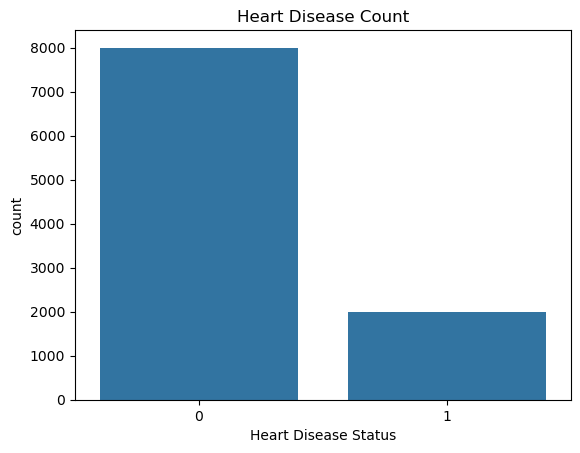


Number of Features: 20


C:\Users\jenif\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\jenif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jenif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: Un


Accuracy: 0.8065

Confusion Matrix:
 [[1613    0]
 [ 387    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89      1613
           1       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000


--- Test Prediction ---
 Low chance of Heart Disease


C:\Users\jenif\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


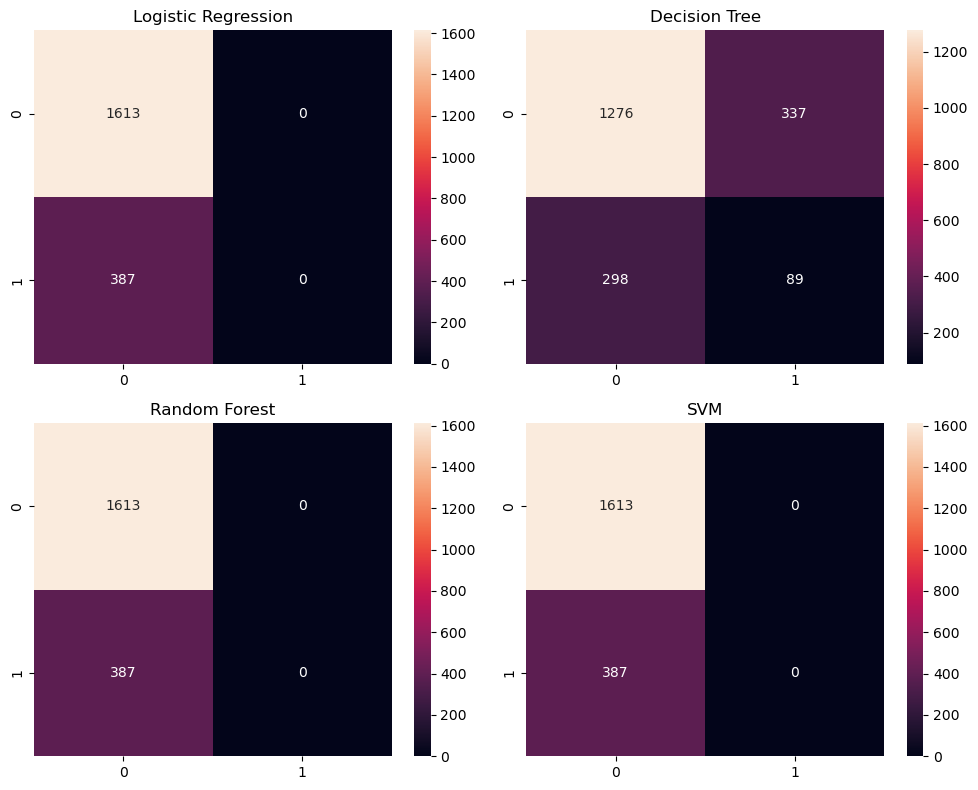

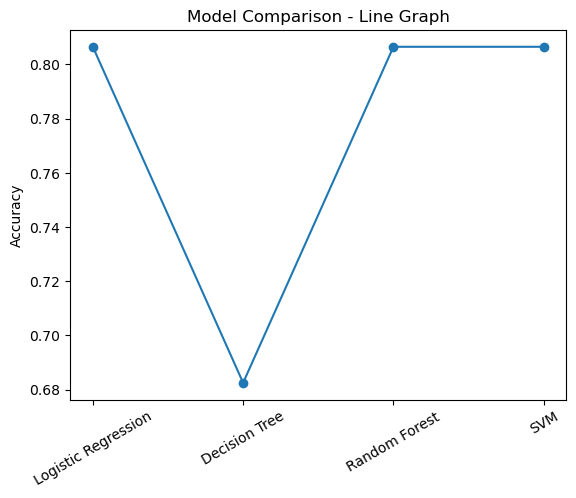

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
data = pd.read_csv("heart.csv")
print("Columns:\n", data.columns)
target_column = data.columns[-1]
print("\nTarget Column:", target_column)
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes
data = data.fillna(data.mean())
print("\nMissing Values:\n", data.isnull().sum())
plt.figure()
sns.countplot(x=target_column, data=data)
plt.title("Heart Disease Count")
plt.show()
X = data.drop(target_column, axis=1)
y = data[target_column]
print("\nNumber of Features:", X.shape[1])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\n--- Test Prediction ---")
new_data = X.iloc[0].values.reshape(1, -1)
prediction = model.predict(new_data)
if prediction[0] == 1:
    print(" High chance of Heart Disease")
else:
    print(" Low chance of Heart Disease")
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
models = {
    "Logistic Regression": model,
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}
accuracies = {}
predictions = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred_m = m.predict(X_test)
    predictions[name] = y_pred_m
    accuracies[name] = accuracy_score(y_test, y_pred_m)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()
names = list(accuracies.keys())
values = list(accuracies.values())
plt.figure()
plt.plot(names, values, marker='o')
plt.ylabel("Accuracy")
plt.title("Model Comparison - Line Graph")
plt.xticks(rotation=30)
plt.show()